# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

In [39]:
import pandas as pd

merged_df = pd.read_csv("../data/sf_crime_merged.csv")

print("Size of the dataset:", len(merged_df))
print("Columns in the dataset:", merged_df.columns.tolist())

Size of the dataset: 1773009
Columns in the dataset: ['Unified Category', 'Incident Date', 'Incident Time', 'Police District', 'Incident Code', 'Incident Number', 'Incident Description', 'Latitude', 'Longitude', 'Resolution', 'Source']


In [40]:
# Selected focus crimes with a high accuracy
personal_focus_crimes = [
    "Assault",
    "Burglary",
    "Robbery",
    "Larceny Theft",
    "Motor Vehicle Theft",
    "Fraud",
    "Arson",
    "Forgery And Counterfeiting",
    "Stolen Property",
    "Embezzlement",
    "Prostitution",
    "Missing Person",
    "Warrant",
    "Liquor Laws",
    "Disorderly Conduct",
]
# Filter dataset to personal focus crimes only
focus_df = merged_df[merged_df["Unified Category"].isin(personal_focus_crimes)].copy()
focus_df = focus_df.dropna(subset=["Police District"])
# Normalize district names (the merged data uses both ALL CAPS and Title Case)
focus_df["Police District"] = focus_df["Police District"].str.title()

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

***
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

### Part A Jitter Plots (Assault incidents)

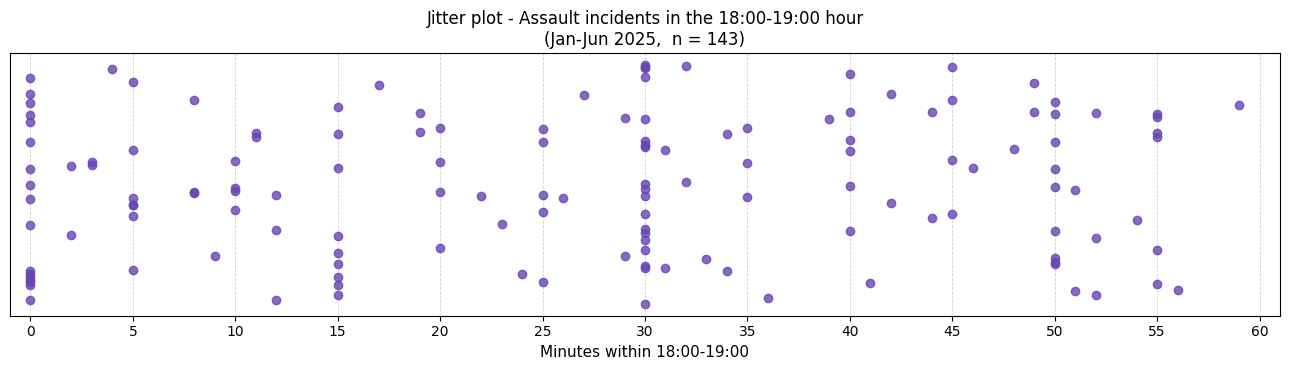

In [41]:
import numpy as np
import matplotlib.pyplot as plt
# Assault category is common enough that 6 months gives 100+ results,
# making time-recording artefacts clearly visible.

assault_df = focus_df[
    (focus_df["Unified Category"] == "Assault")
    & (focus_df["Incident Date"] >= "2025-01-01")
    & (focus_df["Incident Date"] < "2025-07-01")
]


def time_to_hours(t):
    parts = str(t).split(":")
    return int(parts[0]) + int(parts[1]) / 60


assault_df["hour_frac"] = assault_df["Incident Time"].apply(time_to_hours)
assault_df["hour"] = assault_df["hour_frac"].apply(int)

TARGET_HOUR = 18
hour_df = assault_df[assault_df["hour"] == TARGET_HOUR].copy()
hour_df["minute"] = (hour_df["hour_frac"] - TARGET_HOUR) * 60

rng = np.random.default_rng(42)
hour_df["jitter"] = rng.uniform(-0.4, 0.4, size=len(hour_df))

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.scatter(hour_df["minute"], hour_df["jitter"], color="#6845b4", alpha=0.8, zorder=3)

for m in range(0, 61, 5):
    ax.axvline(m, color="lightgrey", linewidth=0.6, linestyle="--", zorder=1)

ax.set_xticks(range(0, 61, 5))
ax.set_xlim(-1, 61)
ax.set_yticks([])
ax.set_xlabel(f"Minutes within {TARGET_HOUR}:00-{TARGET_HOUR + 1}:00", fontsize=11)
ax.set_title(
    f"Jitter plot - Assault incidents in the {TARGET_HOUR}:00-{TARGET_HOUR + 1}:00 hour\n"
    f"(Jan-Jun 2025,  n = {len(hour_df)})",
    fontsize=12,
)

plt.tight_layout()
plt.show()

From the jitter plot we can see that most datapoints are clustered around the hour and half hour. Meaning most incidents in the dataset have an accuracy of ±30 minutes.

### Part B - Probability plot (Robbery & Burglary)

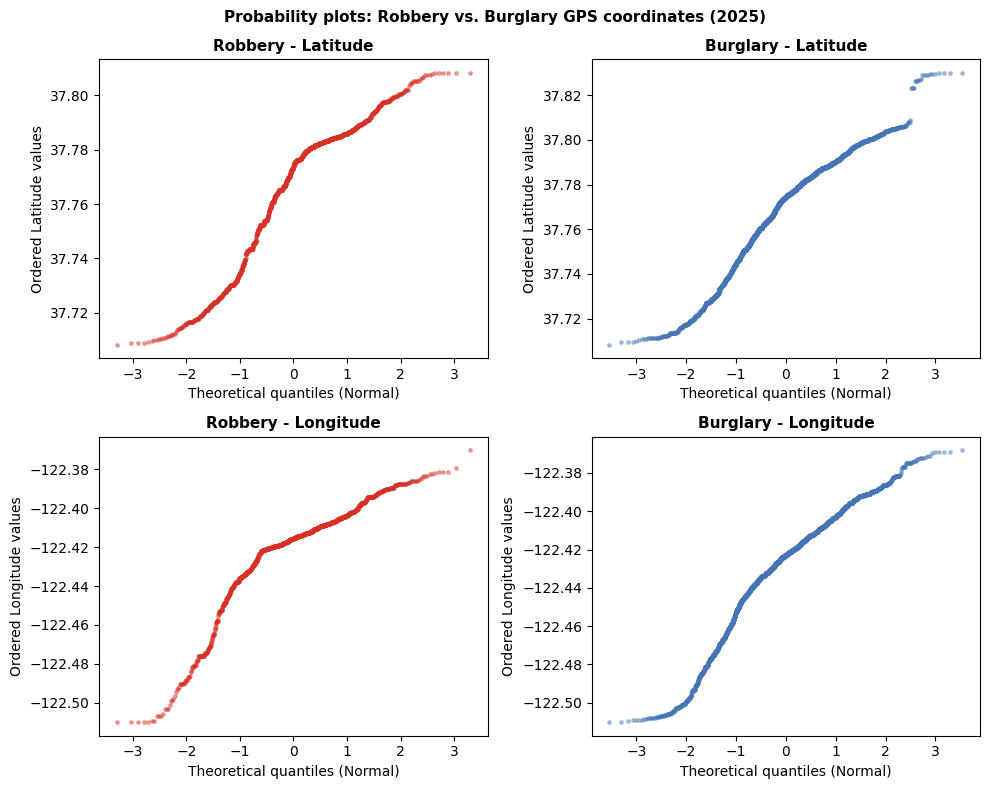

In [42]:
from scipy.stats import probplot

CATEGORIES = ["Robbery", "Burglary"]
COLORS = ["#d73027", "#4575b4"]

probablity_subset = {}
for cat in CATEGORIES:
    probablity_subset[cat] = (
        focus_df[
            (focus_df["Unified Category"] == cat)
            & (focus_df["Incident Date"] >= "2025-01-01")
            & (focus_df["Incident Date"] < "2026-01-01")
        ]
        .dropna(subset=["Latitude", "Longitude"])
        .copy()
    )

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, (cat, color) in enumerate(zip(CATEGORIES, COLORS)):
    for row, (coord, label) in enumerate(
        [("Latitude", "Latitude"), ("Longitude", "Longitude")]
    ):
        ax = axes[row, col]
        data = probablity_subset[cat][coord].dropna().values
        (osm, osr), _ = probplot(data, dist="norm")
        ax.scatter(osm, osr, color=color, alpha=0.4, s=6, zorder=2)
        ax.set_xlabel("Theoretical quantiles (Normal)", fontsize=10)
        ax.set_ylabel(f"Ordered {label} values", fontsize=10)
        ax.set_title(f"{cat} - {label}", fontsize=11, fontweight="bold")

fig.suptitle(
    "Probability plots: Robbery vs. Burglary GPS coordinates (2025)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**Reference distribution:** The standard normal (Gaussian) distribution. Each plot compares the empirical coordinates against the quantiles we would expect if the data were perfectly normally distributed.

**If points fell exactly on the line:** The coordinate would be normally distributed, crimes would be spread symmetrically around a central point, and gradually thins toward the city's edges, with no hotspots or geographic boundaries distorting the pattern.

**Geographic interpretation:** Crime in SF is not spread like a smooth hill centred on one neighbourhood. The heavy-tailed plots reveal a clustered, reflection of SF neighbourhood contrasts, for example dense commercial neighborhoods, quiet residential districts and tourist corridors. A single normal distribution is too simple a model; the deviations expose the hotspot structure that a histogram or mean coordinate would hide.


### Part C — Box plots of time-of-day

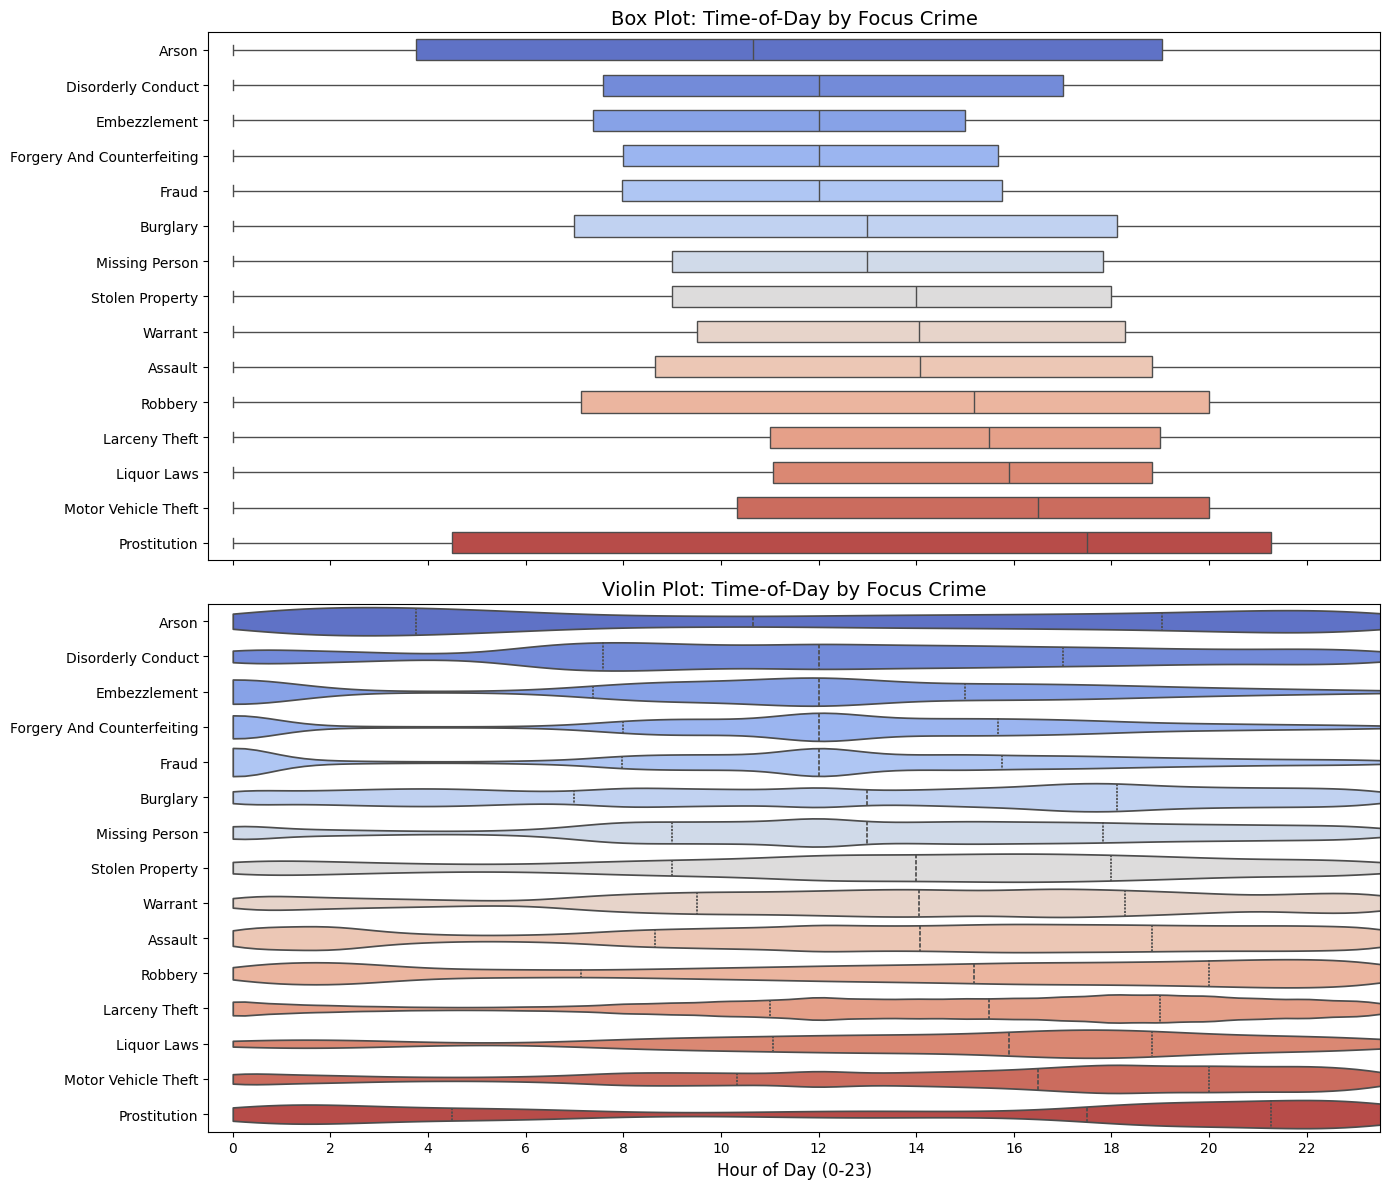

In [49]:
import seaborn as sns


def time_to_frac(t):
    h, m = str(t).split(":")[:2]
    return int(h) + int(m) / 60


focus_df["Hour"] = focus_df["Incident Time"].apply(time_to_frac)
crime_order = (
    focus_df.groupby("Unified Category")["Hour"].median().sort_values().index.tolist()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.boxplot(
    data=focus_df,
    x="Hour",
    y="Unified Category",
    hue="Unified Category",
    order=crime_order,
    hue_order=crime_order,
    legend=False,
    orient="h",
    ax=ax1,
    palette="coolwarm",
    width=0.6,
    fliersize=1,
)
ax1.set_title("Box Plot: Time-of-Day by Focus Crime", fontsize=14)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xlim(-0.5, 23.5)
ax1.set_xticks(range(0, 24, 2))

sns.violinplot(
    data=focus_df,
    x="Hour",
    y="Unified Category",
    hue="Unified Category",
    order=crime_order,
    hue_order=crime_order,
    legend=False,
    orient="h",
    ax=ax2,
    palette="coolwarm",
    inner="quartile",
    cut=0,
)
ax2.set_title("Violin Plot: Time-of-Day by Focus Crime", fontsize=14)
ax2.set_xlabel("Hour of Day (0-23)", fontsize=12)
ax2.set_ylabel("")
ax2.set_xlim(-0.5, 23.5)
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

Several clear patterns emerge from the time-of-day distributions:

**Daytime / business-hours crimes:** Fraud, Embezzlement, and Forgery And Counterfeiting cluster during working hours (roughly 8:00–17:00). This makes sense, since these are white-collar crimes tied to office hours, banking, and commercial activity. Larceny Theft also has some volume during the daytime, which for example could be shoplifting incidents.

**Evening and nighttime crimes:** Assault and Robbery shift toward the evening and night. Prostitution skews heavily toward late night and early morning hours.

**The wrap-around problem:** In our visualization we are plotting the crimes time-of-day in the 00-23 scale, which means the box plot struggles with crimes that peak around midnight. For example prostitution as an example, it's incidents cluster in both the late-night hours (22:00–23:00) and the early morning (0:00–3:00).

**Why the violin plot helps:** The violin plot reveals the full shape of each distribution, not just the five-number summary. This makes it easy to spot skewed patterns that box plots flatten. For Prostitution, you can see peaks at both ends of the 0-23 scale.